In [2]:
import torch 
from torch.utils.data import Dataset, DataLoader
from pyteomics import mgf
import numpy as np
import logging
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch import optim
import networkx as nx
from collections import deque
from matplotlib import pyplot as plt

from sklearn.metrics import (
    adjusted_mutual_info_score as AMI,
    adjusted_rand_score as ARI,
)
import random
import pandas as pd



# model input data preparation

In [3]:
processed_features = pd.read_hdf("./peptdeepwork/processed_features.h5", key="features")
processed_features


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
18080635323514663207,-0.066837,1.242110,0.746972,-0.069704,-0.069538,-0.069381,-0.069236,-0.068794,-0.068469,-0.067082,...,-0.172200,2.558338,-0.627303,0.411093,-0.575519,-0.451568,0.0,1.414214,-0.707107,-0.707107
14669807044004538680,-0.066838,-0.170780,0.725590,-0.069411,-0.069283,-0.069105,-0.069019,-0.068531,-0.068232,-0.066787,...,2.475728,0.805907,2.464574,0.843902,2.549063,1.464245,0.0,1.414214,-0.707107,-0.707107
584780176198780664,-0.068232,-0.312673,-0.937530,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068841,-0.067493,...,-0.630078,2.273397,0.485894,-0.611832,-0.575519,-0.451568,0.0,-0.707107,-0.707107,1.414214
584780176198780663,-0.067843,-0.312673,-0.633082,-0.069779,-0.069715,-0.069576,-0.069496,-0.069076,-0.068701,-0.067345,...,-0.630078,0.393660,-0.627303,-0.570494,-0.575519,-0.451568,0.0,-0.707107,1.414214,-0.707107
584780176198780662,-0.067066,-0.312673,0.364587,-0.069723,-0.069717,-0.069561,-0.069465,-0.068970,-0.068701,-0.067233,...,0.254574,-0.630680,-0.627303,-0.088796,-0.392081,-0.451568,0.0,1.414214,-0.707107,-0.707107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13956871899653124234,-0.066274,1.248301,0.661997,-0.069714,-0.069602,-0.069369,-0.069210,-0.068717,-0.068419,-0.066961,...,-0.331678,-0.522545,-0.440432,1.165769,1.806516,1.052303,0.0,-0.707107,-0.707107,1.414214
16568467721864459869,-0.063709,1.233154,2.434768,-0.067235,-0.067186,-0.067747,-0.067718,-0.067297,-0.067027,-0.065604,...,-0.630078,-0.630680,-0.627303,0.240429,2.568486,-0.451568,0.0,1.414214,-0.707107,-0.707107
16568467721864459870,-0.065605,1.233154,1.378530,-0.067235,-0.067186,-0.067642,-0.067580,-0.067176,-0.066908,-0.065476,...,-0.630078,-0.630680,-0.627303,2.642928,0.706135,-0.451568,0.0,-0.707107,1.414214,-0.707107
17256412178792009832,-0.063746,0.607052,2.259991,-0.067126,-0.067182,-0.067089,-0.067027,-0.066736,-0.066571,-0.065088,...,2.441639,2.558338,2.448579,2.565412,2.497366,3.718322,0.0,1.414214,-0.707107,-0.707107


In [4]:

from sklearn.preprocessing import MinMaxScaler


# Apply Min-Max Scaling
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(processed_features)

# Convert back to DataFrame if needed
normalized_df = pd.DataFrame(normalized_data, columns=processed_features.columns)
normalized_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,0.000114,0.911099,0.492208,0.000070,0.000072,0.000067,0.000068,0.000065,0.000065,0.000060,...,0.145572,1.000000,0.000000,0.314286,0.000000,0.000000,0.0,1.0,0.0,0.0
1,0.000114,0.461883,0.488509,0.000090,0.000090,0.000086,0.000083,0.000083,0.000081,0.000079,...,0.987423,0.450479,0.982555,0.447263,0.993822,0.451014,0.0,1.0,0.0,0.0
2,0.000041,0.416769,0.200823,0.000064,0.000060,0.000054,0.000050,0.000045,0.000039,0.000033,...,0.000000,0.910649,0.353758,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
3,0.000061,0.416769,0.253486,0.000064,0.000060,0.000054,0.000050,0.000045,0.000049,0.000043,...,0.000000,0.321209,0.000000,0.012700,0.000000,0.000000,0.0,0.0,1.0,0.0
4,0.000102,0.416769,0.426063,0.000068,0.000060,0.000055,0.000052,0.000053,0.000049,0.000050,...,0.281256,0.000000,0.000000,0.160699,0.058345,0.000000,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641908,0.000143,0.913068,0.477509,0.000069,0.000068,0.000068,0.000070,0.000070,0.000068,0.000068,...,0.094870,0.033909,0.059385,0.546154,0.757643,0.354036,0.0,0.0,0.0,1.0
641909,0.000277,0.908251,0.784163,0.000240,0.000235,0.000180,0.000173,0.000167,0.000162,0.000155,...,0.000000,0.000000,0.000000,0.261851,1.000000,0.000000,0.0,1.0,0.0,0.0
641910,0.000178,0.908251,0.601455,0.000240,0.000235,0.000187,0.000182,0.000175,0.000170,0.000163,...,0.000000,0.000000,0.000000,1.000000,0.407650,0.000000,0.0,0.0,1.0,0.0
641911,0.000275,0.709188,0.753930,0.000248,0.000235,0.000225,0.000220,0.000205,0.000193,0.000188,...,0.976585,1.000000,0.977472,0.976184,0.977379,0.981660,0.0,1.0,0.0,0.0


Get a sample of the normalized data

In [5]:
normalized_df = normalized_df.dropna()  # Remove rows with NaN values
normalized_df.shape

(594273, 57)

In [6]:
def generate_random_samples(df, sample_size):
    # Shuffle the full DataFrame
    shuffled_df =  df.sample(frac=1)
    

    # Split into chunks of sample_size
    for i in range(0, len(shuffled_df), sample_size):
        yield shuffled_df.iloc[i:i + sample_size]



## Ploting 3d 

In [7]:
def plot_tsne_results(tsne_df, size_multiplier=10, figsize=(12, 8)):
    """
    Visualizes t-SNE results with cluster coloring support and automatic dimensionality handling.
    
    Args:
        tsne_df (pd.DataFrame): DataFrame containing t-SNE coordinates (columns TSNE1, TSNE2...)
        size_multiplier (float): Scaling factor for 4th dimension visualization
        figsize (tuple): Figure size dimensions
    
    Returns:
        matplotlib.figure.Figure: The generated figure object
    """
    # Validate input columns
    tsne_cols = [col for col in tsne_df.columns if col.startswith('TSNE')]
    if not tsne_cols:
        raise ValueError("DataFrame must contain TSNE1, TSNE2... columns")
    n_components = len(tsne_cols)
    if n_components not in [2, 3, 4]:
        raise ValueError("Only 2D, 3D, or 4D t-SNE projections are supported")

    # Configure plot settings
    fig = plt.figure(figsize=figsize)
    color_by_cluster = 'cluster' in tsne_df.columns
    cmap = 'viridis' if color_by_cluster else None
    colors = tsne_df['cluster'] if color_by_cluster else None
    
    # Create appropriate axis
    if n_components >= 3:
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.gca()

    # Get data for plotting
    xs = tsne_df['TSNE1']
    ys = tsne_df['TSNE2']
    zs = tsne_df['TSNE3'] if n_components >= 3 else None
    
    
    # Additional parameters
    kwargs = {'alpha': 0.7}
    if colors is not None:
        kwargs['c'] = colors
        kwargs['cmap'] = cmap
    
    if n_components == 4:
        # Normalize and scale TSNE4 for point sizes
        sizes = (tsne_df['TSNE4'] - tsne_df['TSNE4'].min() + 0.2) * size_multiplier # here threshold of 0.2 is added to avoid zero size
        kwargs['s'] = sizes
    
    # Create scatter plot based on dimensions
    if n_components >= 3:
        sc = ax.scatter(xs, ys, zs, **kwargs)
    else:
        sc = ax.scatter(xs, ys, **kwargs)

    # Add labels and decorations
    ax.set_xlabel('TSNE1')
    ax.set_ylabel('TSNE2')
    if n_components >= 3:
        ax.set_zlabel('TSNE3')
    
    title = f"{n_components}D t-SNE Projection"
    if color_by_cluster:
        title += " (Colored by Cluster)"
    if n_components == 4:
        title += " (Size = TSNE4)"
    plt.title(title)

    # Add colorbar if using clusters
    if color_by_cluster:
        plt.colorbar(sc, label='Cluster', ax=ax)
    
    # Add legend for size if using 4D
    if n_components == 4:
        size_info = f"Size scale: {size_multiplier}x normalized TSNE4"
        plt.legend(*sc.legend_elements(prop='sizes'), title=size_info)

    plt.grid(True)
    return fig


to find similar vectors need to reduce the dimensions using tsne


In [8]:
sample_size = 10000
sample_df = next(generate_random_samples(normalized_df, sample_size))
sample_df


,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
500943,0.000266,0.928247,0.794349,0.000175,0.000169,0.000162,0.000154,0.000147,0.000141,0.000099,...,0.067608,0.315727,0.001005,0.168314,0.186354,0.151127,0.0,1.0,0.0,0.0
536775,0.000136,0.912575,0.469806,0.000148,0.000122,0.000075,0.000072,0.000069,0.000071,0.000070,...,0.119430,0.067926,0.747388,0.019076,0.511837,0.387582,0.0,0.0,1.0,0.0
312947,0.000060,0.707039,0.244995,0.000103,0.000099,0.000093,0.000085,0.000077,0.000055,0.000053,...,1.000000,0.059408,0.052658,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
449864,0.000053,0.879513,0.253677,0.000092,0.000088,0.000081,0.000075,0.000066,0.000062,0.000054,...,0.584999,0.682881,0.135915,0.029353,0.000000,0.000000,0.0,0.0,0.0,1.0
27531,0.000113,0.367335,0.454043,0.000089,0.000087,0.000085,0.000084,0.000078,0.000080,0.000078,...,0.992020,0.446912,0.995404,0.445018,1.000000,0.449127,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342506,0.000077,0.125849,0.312884,0.000119,0.000112,0.000104,0.000093,0.000082,0.000057,0.000056,...,0.113736,1.000000,0.427334,0.039014,0.056060,0.000000,0.0,0.0,0.0,1.0
319404,0.000054,0.320946,0.245072,0.000084,0.000081,0.000075,0.000066,0.000058,0.000046,0.000045,...,0.037397,0.106252,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
155360,0.000089,0.323828,0.405967,0.000045,0.000046,0.000043,0.000042,0.000038,0.000037,0.000033,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0
545603,0.000138,0.926586,0.537069,0.000163,0.000158,0.000151,0.000144,0.000137,0.000135,0.000127,...,0.223770,0.156248,0.075826,0.565485,1.000000,0.000000,0.0,0.0,1.0,0.0


In [1]:
# from sklearn.manifold import TSNE

# tsne = TSNE(
#     n_components=4, 
#     method='exact',
#     learning_rate='auto',
#     random_state=43, 
#     perplexity=30,  #perplexity must be less than n_samples
#     n_iter=1000,
#     )
# tsneResult = tsne.fit_transform(sample_df)
# tsne_result=pd.DataFrame(tsneResult,columns=['TSNE1','TSNE2','TSNE3',"TSNE4"])

In [9]:
# tsne_plot_df = tsne_result  # Add cluster column if exists
# plot_tsne_results(tsne_plot_df, size_multiplier=1)
# plt.show()

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def tsne_and_similarity(row1, row2, similarity_threshold=0.1):
    """
    Reduces two rows to 2D using t-SNE, plots them, and calculates their similarity.
    
    Args:
        row1 (list): First row of data.
        row2 (list): Second row of data.
        similarity_threshold (float): Threshold for determining similarity.

    Returns:
        dict: A dictionary containing reduced coordinates, distance, and similarity status.
    """
    # Combine the two rows into a single dataset
    data = np.array([row1, row2])

    # Apply t-SNE to reduce dimensions to 2
    tsne = TSNE(n_components=2, method='exact', random_state=42, perplexity=1)
    reduced_data = tsne.fit_transform(data)

    # Plot the two points with different colors
    plt.figure(figsize=(6, 6))
    plt.scatter(reduced_data[0, 0], reduced_data[0, 1], color='blue', label='Row 1')
    plt.scatter(reduced_data[1, 0], reduced_data[1, 1], color='red', label='Row 2')
    plt.legend()
    plt.title('t-SNE Projection of Two Rows')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.grid(True)
    plt.show()

    # Calculate Euclidean distance between the original rows
    distance = np.linalg.norm(np.array(row1) - np.array(row2))

    # Determine similarity based on the threshold
    similarity = 'Similar' if distance < similarity_threshold else 'Non-Similar'

    return {
        "reduced_coordinates": reduced_data,
        "distance": distance,
        "similarity": similarity
    }

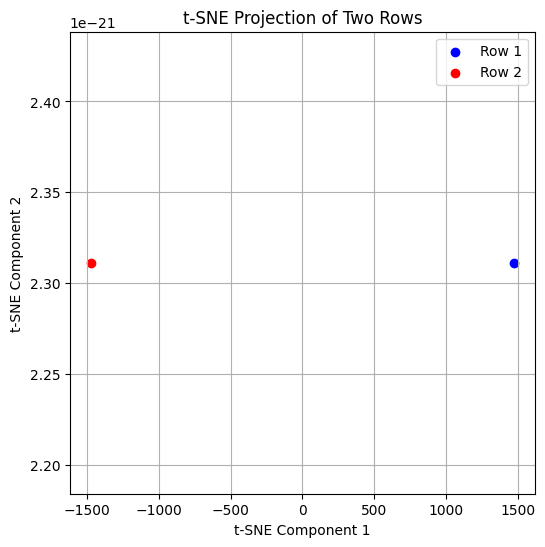

{'reduced_coordinates': array([[ 1.4735293e+03,  2.3112549e-21],
       [-1.4735293e+03,  2.3112549e-21]], dtype=float32), 'distance': 1.5011095791446507, 'similarity': 'Non-Similar'}


In [11]:
row1 = sample_df.iloc[3] 
row2 = sample_df.iloc[2] 

result = tsne_and_similarity(row1, row2)
print(result)

Creating the DBScan


In [ ]:
# class DBSCANBase:
#     def __init__(self, eps, minPts):
#         self._eps = eps
#         self._minPts = minPts

#     def fit(self, X):
#         pass

#     def score(self, X, y):
#         y_pred = self.predict(X)
#         return (AMI(y, y_pred), ARI(y, y_pred))

#     def predict(self, X):
#         pass

In [ ]:
# class DBSCANGraphBased(DBSCANBase):
    
#     def __init__(self, eps, minPts):
#         super().__init__(eps, minPts)
#     def fit(self, X):
#         self._construct_graph(X)
#         self._get_clusters()
#         self._get_centroids(X)
#         self._cluster_outliers(X)

#     def predict(self, X):
#         y = []
#         for x in X:
#             distances = {
#                 label: self._distance(x, centroid)
#                 for label, centroid in self._centroids.items()
#             }
#             y.append(min(distances, key=distances.get))
#         return y

#     def _construct_graph(self, X):
#         cardinality = len(X)
#         graph = nx.Graph()
#         graph.add_nodes_from(
#             list(range(cardinality)), is_core=False, visited=False, cluster=None
#         )
#         for i in range(cardinality):
#             for j in range(i + 1, cardinality):
#                 if self._distance(X[i], X[j]) < self._eps:
#                     graph.add_edge(i, j)
#             if graph.degree[i] >= self._minPts:
#                 graph.nodes[i]["is_core"] = True
#         self._graph = graph

#     def _get_clusters(self):
#         cluster_label = 0
#         for node in self._graph:
#             if not self._graph.nodes[node]["visited"] and self._graph.nodes[node][
#                 "is_core"
#             ]:
#                 self._graph.nodes[node]["visited"] = True
#                 self._graph.nodes[node]["cluster"] = cluster_label
#                 self._bfs_node(node, cluster_label)
#                 cluster_label += 1
#         self._num_clusters = cluster_label

#     def _bfs_node(self, source, cluster_label):
#         neighbors = self._graph.neighbors
#         queue = deque([(source, len(self._graph), neighbors(source))])
#         while queue:
#             _, depth_now, children = queue[0]
#             try:
#                 child = next(children)
#                 if not self._graph.nodes[child]["visited"]:
#                     self._graph.nodes[child]["visited"] = True
#                     self._graph.nodes[child]["cluster"] = cluster_label
#                     if depth_now > 1:
#                         queue.append((child, depth_now - 1, neighbors(child)))
#             except StopIteration:
#                 queue.popleft()

#     def _get_centroids(self, X):
#         self._centroids = {}
#         for i in range(self._num_clusters):
#             X_list = []
#             for node in self._graph:
#                 if self._graph.nodes[node]["cluster"] == i:
#                     X_list.append(X[i])
#             self._centroids.update({i: np.mean(X_list, axis=0)})

#     def _cluster_outliers(self, X):
#         for node in self._graph:
#             if self._graph.nodes[node]["cluster"] is None:
#                 self._graph.nodes[node]["cluster"] = self.predict(X[node])

#     @staticmethod
#     def _distance(p1, p2):
#         return np.linalg.norm(p1 - p2)


In [12]:
from sklearn.cluster import DBSCAN

def perform_dbscan_clustering(data, eps=1.3, min_samples=4):
    """
    Perform DBSCAN clustering on the given data.

    Args:
        data (pd.DataFrame): The input data to cluster.
        eps (float): Maximum distance between two samples for them to be considered as in the same neighborhood.
        min_samples (int): Minimum number of neighbors (including the point itself) for a point to be considered a core point.

    Returns:
        np.ndarray: Cluster labels for each point in the dataset.
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    cluster_labels = dbscan.fit_predict(data)
    return cluster_labels

# # Example usage
# cluster_labels = perform_dbscan_clustering(sample_df)
# cluster_labels

In [13]:
all_samples = []
cluster_offset = 0  # Start cluster labels from 0

for sample_df in generate_random_samples(normalized_df, sample_size):
    cluster_labels = perform_dbscan_clustering(sample_df)

    # Adjust cluster labels to be globally unique
    adjusted_labels = []
    for label in cluster_labels:
        if label == -1:
            adjusted_labels.append(-1)  # Keep noise label as -1
        else:
            adjusted_labels.append(label + cluster_offset)

    num_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    print(f"Number of clusters found: {num_clusters}")

    sample_df['cluster'] = adjusted_labels
    all_samples.append(sample_df)

    # Update offset for next iteration
    cluster_offset += num_clusters

# Combine all sample dataframes into one
final_df = pd.concat(all_samples, ignore_index=True)


Number of clusters found: 6


C:\Users\havin\AppData\Local\Temp\ipykernel_26664\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 8


C:\Users\havin\AppData\Local\Temp\ipykernel_26664\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 9


...

C:\Users\havin\AppData\Local\Temp\ipykernel_26664\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 8


C:\Users\havin\AppData\Local\Temp\ipykernel_26664\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


Number of clusters found: 7
Number of clusters found: 6


C:\Users\havin\AppData\Local\Temp\ipykernel_26664\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels
C:\Users\havin\AppData\Local\Temp\ipykernel_26664\2367456850.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['cluster'] = adjusted_labels


In [15]:
final_df

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,cluster
0,0.000155,0.913329,0.488079,0.000217,0.000212,0.000209,0.000196,0.000189,0.000182,0.000172,...,0.987905,0.998849,0.995765,0.995260,0.997663,0.0,0.0,1.0,0.0,0
1,0.000286,0.926094,0.798556,0.000231,0.000216,0.000172,0.000165,0.000158,0.000153,0.000146,...,0.000000,0.281115,0.175929,1.000000,0.000000,0.0,1.0,0.0,0.0,1
2,0.000070,0.467438,0.291169,0.000077,0.000073,0.000068,0.000065,0.000058,0.000062,0.000053,...,0.231816,0.007569,0.000000,0.015035,0.000000,0.0,0.0,1.0,0.0,2
3,0.000150,0.923112,0.591672,0.000068,0.000064,0.000067,0.000063,0.000062,0.000065,0.000065,...,0.135412,0.257851,0.111460,0.069102,0.042781,0.0,0.0,1.0,0.0,2
4,0.000056,0.020070,0.276817,0.000034,0.000032,0.000032,0.000027,0.000024,0.000023,0.000020,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594268,0.000072,0.484739,0.297683,0.000078,0.000082,0.000072,0.000065,0.000058,0.000049,0.000042,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,462
594269,0.000129,0.668150,0.519793,0.000102,0.000099,0.000099,0.000099,0.000093,0.000095,0.000088,...,0.439149,0.982503,0.438893,1.000000,0.440714,0.0,1.0,0.0,0.0,464
594270,0.000069,0.492917,0.289346,0.000086,0.000084,0.000079,0.000071,0.000065,0.000059,0.000051,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,1.0,0.0,462
594271,0.000132,0.852557,0.396345,0.000088,0.000073,0.000068,0.000061,0.000061,0.000062,0.000063,...,0.119181,0.060404,0.060201,0.027091,0.006336,0.0,0.0,1.0,0.0,462


In [22]:
# Suppose the flag is a string: 'pearson', 'spearman', or 'kendall'
flag = 'spearman'  # you can change this dynamically

# Compute correlation
correlation_matrix = final_df.drop(columns=['cluster']).corr(method=flag)

print(correlation_matrix)


          0             1         2         3         4         5         6   \
0   1.000000  5.927011e-01  0.973257  0.799524  0.800090  0.815905  0.834516   
1   0.592701  1.000000e+00  0.581687  0.586979  0.569554  0.566643  0.568039   
2   0.973257  5.816866e-01  1.000000  0.745663  0.748909  0.766762  0.787062   
3   0.799524  5.869785e-01  0.745663  1.000000  0.987006  0.977031  0.966497   
4   0.800090  5.695543e-01  0.748909  0.987006  1.000000  0.989952  0.979796   
5   0.815905  5.666430e-01  0.766762  0.977031  0.989952  1.000000  0.990670   
6   0.834516  5.680394e-01  0.787062  0.966497  0.979796  0.990670  1.000000   
7   0.850193  5.728223e-01  0.803272  0.957094  0.968263  0.981783  0.990983   
8   0.863915  5.784320e-01  0.817053  0.947900  0.957627  0.970378  0.983004   
9   0.874196  5.857090e-01  0.826651  0.941826  0.949106  0.962092  0.973247   
10  0.881239  5.937520e-01  0.832670  0.937968  0.943610  0.955152  0.966743   
11  0.884726  6.018644e-01  0.834851  0.

<Axes: >

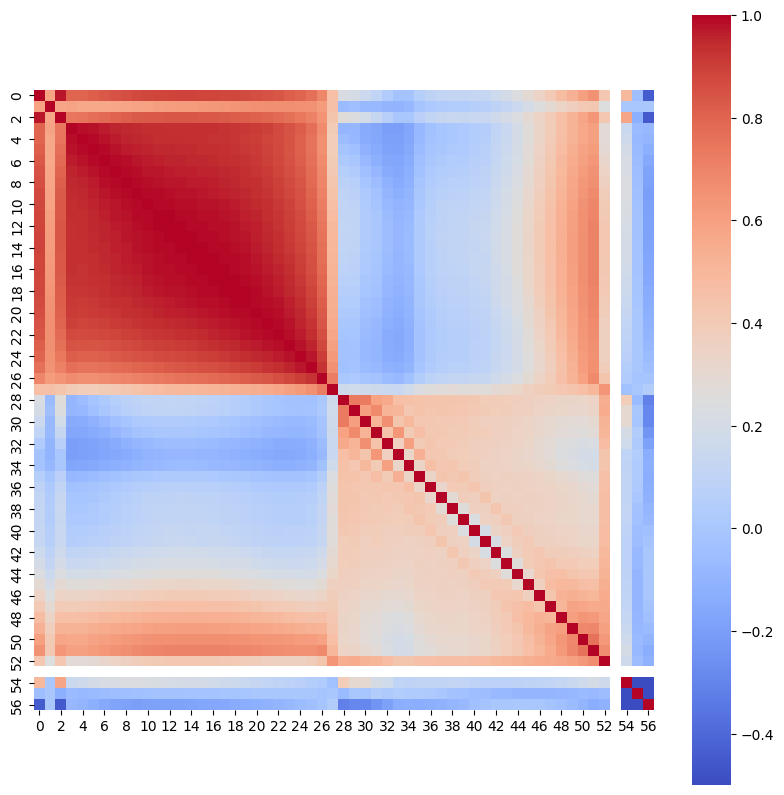

In [21]:
import seaborn as sns
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap='coolwarm', square=True)

In [ ]:

cluster_counts = pd.Series(final_df).value_counts()
print(cluster_counts)
len(cluster_counts)


 2    330
 1    327
 0    272
-1     42
 4     15
 6      5
 5      5
 3      4
Name: count, dtype: int64


8

In [ ]:
sample_df_with_cluster_labels = sample_df.copy()
sample_df_with_cluster_labels['cluster'] = cluster_labels
sample_df_with_cluster_labels

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,cluster
153419,0.000029,0.117008,0.149785,0.000048,0.000039,0.000034,0.000033,0.000027,0.000026,0.000023,...,0.000000,0.003927,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,0
501107,0.000084,0.845953,0.352549,0.000139,0.000130,0.000122,0.000115,0.000108,0.000105,0.000093,...,0.103977,0.057311,0.289924,0.235665,0.000000,0.0,0.0,0.0,1.0,1
349093,0.000091,0.898189,0.328742,0.000090,0.000087,0.000080,0.000072,0.000063,0.000059,0.000056,...,0.712460,0.055302,0.086068,0.058743,0.002837,0.0,0.0,1.0,0.0,2
564619,0.000158,0.904941,0.445114,0.000180,0.000175,0.000158,0.000121,0.000083,0.000083,0.000082,...,0.167651,1.000000,0.206070,0.007800,0.339330,0.0,0.0,1.0,0.0,0
563125,0.000147,0.918951,0.447605,0.000193,0.000189,0.000162,0.000155,0.000153,0.000152,0.000145,...,0.261077,0.000000,0.000000,0.000201,0.000000,0.0,0.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268742,0.000037,0.640110,0.175079,0.000059,0.000054,0.000050,0.000043,0.000037,0.000032,0.000033,...,0.397477,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,-1
121877,0.000023,0.366628,0.138131,0.000042,0.000039,0.000035,0.000027,0.000024,0.000027,0.000019,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0,0
501119,0.000098,0.773404,0.390799,0.000171,0.000142,0.000135,0.000117,0.000106,0.000078,0.000074,...,0.100224,0.156422,0.018675,0.281335,0.157700,0.0,0.0,0.0,1.0,1
586856,0.000115,0.953539,0.491949,0.000069,0.000061,0.000056,0.000054,0.000052,0.000054,0.000052,...,0.062190,0.098545,0.412780,0.059496,0.195050,0.0,0.0,0.0,1.0,2


In [ ]:


tsne_result_with_cluster_labels = tsne_result.copy()
tsne_result_with_cluster_labels['cluster'] = cluster_labels
tsne_result_with_cluster_labels

,TSNE1,TSNE2,TSNE3,TSNE4,cluster
0,3.642154,-6.964919,-8.474648,0.764286,0
1,-2.138319,-9.871323,-1.139504,0.582502,1
2,1.632741,6.185557,-1.394490,-5.816950,2
3,-0.808314,2.456214,5.238321,-6.387163,0
4,1.316360,5.355607,1.460711,-2.750573,1
...,...,...,...,...,...
995,0.439042,-8.423285,-10.936315,5.695099,-1
996,-0.203201,-6.784640,-9.144449,4.669401,0
997,-4.606977,-11.741348,-5.546647,1.578991,1
998,-1.746078,-9.506223,-7.086671,-2.707710,2


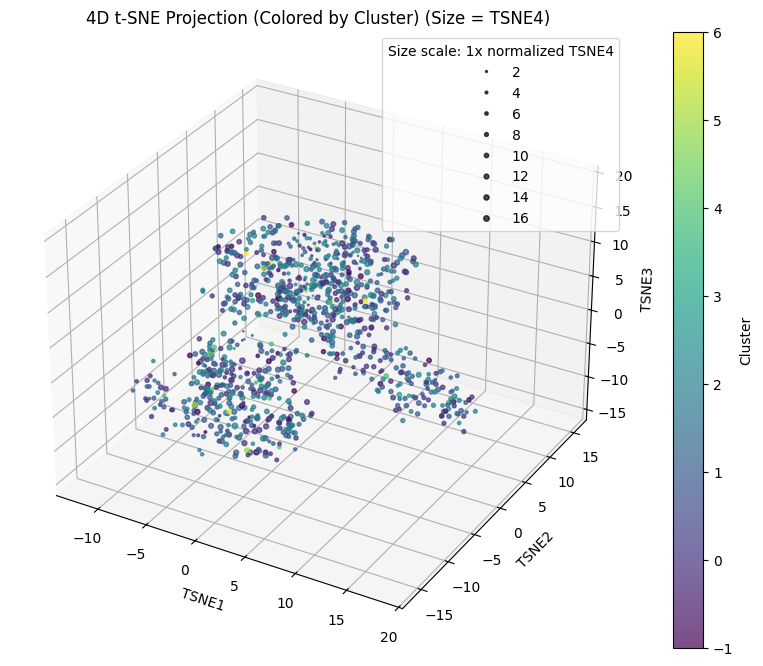

In [ ]:

plot_tsne_results(tsne_result_with_cluster_labels, size_multiplier=1)
plt.show()

## Creating Siamese Pairs 

In [ ]:
sample_df

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
153419,0.000029,0.117008,0.149785,0.000048,0.000039,0.000034,0.000033,0.000027,0.000026,0.000023,...,0.000000,0.000000,0.003927,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
501107,0.000084,0.845953,0.352549,0.000139,0.000130,0.000122,0.000115,0.000108,0.000105,0.000093,...,0.097193,0.103977,0.057311,0.289924,0.235665,0.000000,0.0,0.0,0.0,1.0
349093,0.000091,0.898189,0.328742,0.000090,0.000087,0.000080,0.000072,0.000063,0.000059,0.000056,...,0.698956,0.712460,0.055302,0.086068,0.058743,0.002837,0.0,0.0,1.0,0.0
564619,0.000158,0.904941,0.445114,0.000180,0.000175,0.000158,0.000121,0.000083,0.000083,0.000082,...,0.340528,0.167651,1.000000,0.206070,0.007800,0.339330,0.0,0.0,1.0,0.0
563125,0.000147,0.918951,0.447605,0.000193,0.000189,0.000162,0.000155,0.000153,0.000152,0.000145,...,0.000000,0.261077,0.000000,0.000000,0.000201,0.000000,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268742,0.000037,0.640110,0.175079,0.000059,0.000054,0.000050,0.000043,0.000037,0.000032,0.000033,...,0.000000,0.397477,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
121877,0.000023,0.366628,0.138131,0.000042,0.000039,0.000035,0.000027,0.000024,0.000027,0.000019,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.0
501119,0.000098,0.773404,0.390799,0.000171,0.000142,0.000135,0.000117,0.000106,0.000078,0.000074,...,0.279126,0.100224,0.156422,0.018675,0.281335,0.157700,0.0,0.0,0.0,1.0
586856,0.000115,0.953539,0.491949,0.000069,0.000061,0.000056,0.000054,0.000052,0.000054,0.000052,...,0.067074,0.062190,0.098545,0.412780,0.059496,0.195050,0.0,0.0,0.0,1.0


creating siamese pairs and load with a data loader 

In [ ]:
def calculate_cosine_similarity(vec1, vec2):
    """
    Calculate cosine similarity between two vectors.
    
    Args:
        vec1 (torch.Tensor): First vector.
        vec2 (torch.Tensor): Second vector.
    
    Returns:
        float: Cosine similarity value.
    """
    # Convert rows to tensors and add batch dimension if needed
    vec1 = torch.tensor(vec1.values, dtype=torch.float32)
    vec2 = torch.tensor(vec2.values, dtype=torch.float32)
    
    return F.cosine_similarity(vec1, vec2, dim=0).item()

In [ ]:

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

def create_siamese_pairs(df, pairs_per_cluster=1000, test_size=0.2):
    """
    Creates positive/negative pairs for Siamese network training from clustered data
    
    Args:
        df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
        pairs_per_cluster: Number of pairs to generate per cluster
        test_size: Proportion of data for validation
    
    Returns:
        (train_loader, val_loader): PyTorch DataLoader objects for training
    """
    # Validate input
    if 'cluster' not in df.columns:
        raise ValueError("DataFrame must contain 'cluster' column")
    
    features = df.drop('cluster', axis=1)
    clusters = df['cluster'].values
    unique_clusters = np.unique(clusters)
    
    # Storage for pairs and labels
    pairs = []
    labels = []
    similar_pairs = []
    dissimilar_pairs = []
    
    # Generate pairs for each cluster
    for cluster in unique_clusters:
        print(f"Processing cluster {cluster}...")
        # need to handle clusters of -1 (noise points in DBSCAN)
        if cluster == -1:
            continue
        # Get indices for current cluster
        cluster_indices = np.where(clusters == cluster)[0]
        
        # Skip clusters with < 2 samples
        if len(cluster_indices) < 2:
            continue
            
        # Positive pairs (same cluster)
        count = 0
        for i in range(pairs_per_cluster):
            count += 1
            if( count % 10 == 1):
                print(f"Processed {count} pairs for cluster {cluster}...")    
            
            # Randomly select two different samples from cluster
            similar_try_count = 0
            while True:
                if similar_try_count > 300:
                    print("Too many tries to find a similar pair")
                    break
                similar_try_count += 1
                idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
                if cos_sim > 0.9:
                    print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
                    pairs.append([features.iloc[idx1], features.iloc[idx2]])
                    similar_pairs.append([idx1, idx2])
                    labels.append(0)
                    break
            
            # pairs.append([features[idx1], features[idx2]])
            # labels.append(0)
            
            # Negative pair (different cluster)
            dissimilar_try_count = 0
            while True:
                # Randomly select a sample from the different clusters
                if dissimilar_try_count > 300:
                    print("Too many tries to find a dissimilar pair")
                    break
                dissimilar_try_count += 1

                other_clusters = unique_clusters[unique_clusters != cluster]
                other_cluster = np.random.choice(other_clusters)
                other_indices = np.where(clusters == other_cluster)[0]
                idx3 = np.random.choice(other_indices)
                
                cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
                if cos_sim < 0.1:
                    print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
                    pairs.append([features.iloc[idx1], features.iloc[idx3]])
                    dissimilar_pairs.append([idx1, idx3])
                    labels.append(1)
                    break
                
            # other_clusters = unique_clusters[unique_clusters != cluster]
            # other_cluster = np.random.choice(other_clusters)
            # other_indices = np.where(clusters == other_cluster)[0]
            # idx3 = np.random.choice(other_indices)
            # pairs.append([features[idx1], features[idx3]])
            # labels.append(1)
    
    # Convert to arrays
    pairs = np.array(pairs)
    labels = np.array(labels)
    
    print(f"Total pairs: {len(pairs)}, Total labels: {len(labels)}")
    print(f"Similar pairs: {len(similar_pairs)}, Dissimilar pairs: {len(dissimilar_pairs)}")
    
    
    # Shuffle and split
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    pairs = pairs[indices]
    labels = labels[indices]
    
    # Split into train/validation
    X_train, X_val, y_train, y_val = train_test_split(
        pairs, labels, test_size=test_size, stratify=labels
    )
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_val = torch.FloatTensor(X_val)
    y_train = torch.LongTensor(y_train)
    y_val = torch.LongTensor(y_val)
    
    print("X_train shape:", X_train.shape)
    print("X_val shape:", X_val.shape)
    print("y_train shape:", y_train.shape)

    # Create DataLoaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    
    train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=100)
    
    return train_loader, val_loader

# Usage example
# train_loader, val_loader = create_siamese_pairs(your_dataframe)



In [ ]:
train_loader, val_loader = create_siamese_pairs(sample_df_with_cluster_labels)

Processing cluster -1...
Processing cluster 0...
Processed 1 pairs for cluster 0...
idx1: 306, idx2: 93, cos_sim: 0.9562861323356628
idx1: 306, idx3: 537, cos_sim: 0.05885155126452446
idx1: 636, idx2: 465, cos_sim: 0.9355367422103882


Too many tries to find a dissimilar pair
idx1: 231, idx2: 6, cos_sim: 0.9012258052825928
idx1: 231, idx3: 761, cos_sim: 0.055887747555971146
idx1: 6, idx2: 231, cos_sim: 0.9012258052825928
idx1: 6, idx3: 761, cos_sim: 0.0334327295422554
idx1: 414, idx2: 939, cos_sim: 0.9342101812362671
Too many tries to find a dissimilar pair
idx1: 939, idx2: 825, cos_sim: 0.9310599565505981
Too many tries to find a dissimilar pair
idx1: 243, idx2: 588, cos_sim: 0.952163577079773
idx1: 243, idx3: 87, cos_sim: 0.03328343480825424
Too many tries to find a similar pair
idx1: 486, idx3: 65, cos_sim: 0.08917347341775894
idx1: 672, idx2: 240, cos_sim: 0.983015239238739
Too many tries to find a dissimilar pair
idx1: 747, idx2: 822, cos_sim: 0.9680685997009277
Too many tries to find a dissimilar pair
Processed 11 pairs for cluster 0...
idx1: 477, idx2: 342, cos_sim: 0.945930004119873
idx1: 477, idx3: 922, cos_sim: 0.09521538764238358
idx1: 822, idx2: 231, cos_sim: 0.9439982175827026
Too many tries to find a di

verify siamese pair


In [ ]:

# from sklearn.model_selection import train_test_split
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, TensorDataset

# def create_siamese_pairs_temp(df, pairs_per_cluster=1000, test_size=0.2):
#     """
#     Creates positive/negative pairs for Siamese network training from clustered data
    
#     Args:
#         df (pd.DataFrame): DataFrame with feature vectors and 'cluster' column
#         pairs_per_cluster: Number of pairs to generate per cluster
#         test_size: Proportion of data for validation
    
#     Returns:
#         (train_loader, val_loader): PyTorch DataLoader objects for training
#     """
#     # Validate input
#     if 'cluster' not in df.columns:
#         raise ValueError("DataFrame must contain 'cluster' column")
    
#     features = df.drop('cluster', axis=1)
#     clusters = df['cluster'].values
#     unique_clusters = np.unique(clusters)
    
#     # Storage for pairs and labels
#     similarPairsIndices = []
#     dissimilarPairsIndices = []
#     pairs = []
#     labels = []
    
#     # Generate pairs for each cluster
#     for cluster in unique_clusters:
#         print(f"Processing cluster {cluster}...")
#         if cluster == -1:
#             continue
#         # Get indices for current cluster
#         cluster_indices = np.where(clusters == cluster)[0]
        
#         # Skip clusters with < 2 samples
#         if len(cluster_indices) < 2:
#             continue
            
#         # Positive pairs (same cluster)
#         count = 0 
#         for i in range(pairs_per_cluster):
#             if(count % 10 ==0):
#                 count += 1
#                 print(f"Processing cluster {cluster}...{count}")
#             # Randomly select two different samples from cluster
#             similar_try_count = 0
#             while True:
#                 if similar_try_count > 300:
#                     print("Too many tries to find a similar pair")
#                     break
#                 similar_try_count += 1
#                 idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
#                 if cos_sim > 0.9:
#                     print(f"idx1: {idx1}, idx2: {idx2}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx2]])
#                     similarPairsIndices.append([idx1, idx2])
#                     labels.append(0)
#                     break
            
#             # idx1, idx2 = np.random.choice(cluster_indices, 2, replace=False)
#             # cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx2])
            
            
#             # pairs.append([features.iloc[idx1], features.iloc[idx2]])
#             # similarPairsIndices.append([idx1, idx2])
#             # labels.append(0)
            
#             # Negative pair (different cluster)
            
#             dissimilar_try_count = 0
#             while True:
                
#                 if dissimilar_try_count > 300:
#                     print("Too many tries to find a dissimilar pair")
#                     break
#                 dissimilar_try_count += 1

#                 other_clusters = unique_clusters[unique_clusters != cluster]
#                 other_cluster = np.random.choice(other_clusters)
#                 other_indices = np.where(clusters == other_cluster)[0]
#                 idx3 = np.random.choice(other_indices)
                
#                 cos_sim = calculate_cosine_similarity(features.iloc[idx1], features.iloc[idx3])
#                 if cos_sim < 0.4:
#                     print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#                     pairs.append([features.iloc[idx1], features.iloc[idx3]])
#                     dissimilarPairsIndices.append([idx1, idx3])
#                     labels.append(1)
#                     break
                
#             # other_clusters = unique_clusters[unique_clusters != cluster]
#             # other_cluster = np.random.choice(other_clusters)
#             # other_indices = np.where(clusters == other_cluster)[0]
#             # idx3 = np.random.choice(other_indices)
            
            
#             # print(f"idx1: {idx1}, idx3: {idx3}, cos_sim: {cos_sim}")
#             # pairs.append([features.iloc[idx1], features.iloc[idx3]])
#             # dissimilarPairsIndices.append([idx1, idx3])
#             # labels.append(1)
    
#     # Convert to arrays
#     pairs = np.array(pairs)
#     labels = np.array(labels)
    
#     # Shuffle and split
#     indices = np.arange(len(labels))
#     np.random.shuffle(indices)
#     pairs = pairs[indices]
#     labels = labels[indices]
    
#     return pairs, labels, similarPairsIndices, dissimilarPairsIndices
    
#     # # Split into train/validation
#     # X_train, X_val, y_train, y_val = train_test_split(
#     #     pairs, labels, test_size=test_size, stratify=labels
#     # )
    
#     # # Convert to PyTorch tensors
#     # X_train = torch.FloatTensor(X_train)
#     # X_val = torch.FloatTensor(X_val)
#     # y_train = torch.LongTensor(y_train)
#     # y_val = torch.LongTensor(y_val)
    
#     # # Create DataLoaders
#     # train_dataset = TensorDataset(X_train, y_train)
#     # val_dataset = TensorDataset(X_val, y_val)
    
#     # train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
#     # val_loader = DataLoader(val_dataset, batch_size=100)
    
#     # return train_loader, val_loader

# # Usage example
# # train_loader, val_loader = create_siamese_pairs(your_dataframe)


# pairs, labels, similar, dissimilar  = create_siamese_pairs_temp(sample_df_with_cluster_labels)

# len(similar) +len(dissimilar)
# len(similar) 
# len(dissimilar)

In [ ]:
# sample_df_with_cluster_labels.iloc[similar[1000]]

In [ ]:
# i = 2000
# plot_tsne_results(tsne_result_with_cluster_labels.iloc[similar[i]], size_multiplier=100)
# calculate_cosine_similarity(sample_df_with_cluster_labels.iloc[similar[i][0]], sample_df_with_cluster_labels.iloc[similar[i][1]])

# Loading the deconvoluted spectra using a dataloader

In [ ]:
# class SpectrumDataset(Dataset):
#     def __init__(self,mgf_file_path, max_peaks=200):
#         self.mgf_file_path = mgf_file_path
#         self.max_peaks = max_peaks
#         self.spectra = list(mgf.read(mgf_file_path))
        
#     def __len__(self):
#         return len(self.spectra)

#     def __getitem__(self, index):
#         spectrum = self.spectra[index]
#         mz_values = spectrum.get("m/z array", np.array([]))
#         intensity_values = spectrum.get("intensity array", np.array([]))
        
#         # normalize intensities
#         intensity_values = intensity_values / np.max(intensity_values) if intensity_values.size else intensity_values

#         return torch.tensor(np.stack(mz_values,intensity_values), axis=1)

In [ ]:
class SiamesNetwork(nn.Module):
    def __init__(self, input_dim=57):
        super(SiamesNetwork, self).__init__()
        
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,32),
            nn.SELU(),
            nn.Linear(32,50),
            nn.SELU()            
        )
        # self.cnn11 = nn.Sequential(
        #     nn.Conv1d(1,30,3),
        #     nn.SELU(),
        #     nn.MaxPool1d(2),
        #     nn.SELU()
        # )
        
        self.cnn21 = nn.Sequential(
            nn.Conv1d(1,30,3),
            nn.SELU(),
            nn.MaxPool1d(2),
            nn.SELU(),
            nn.Conv1d(30,30,3),
            nn.MaxPool1d(2),
            nn.SELU()
        )
        self.fc2 =nn.Linear(330,32)
    # (3000x11 and 25775x32)
    def forward_once(self, x):
        # Get feature embeddings
        x = self.fc1(x)
        # torch.Size([100, 50])
        
        x = x.unsqueeze(1)
        # ([100, 1, 50])
        x = self.cnn21(x)
        # [100, 30, 11]
        
        
        x = x.view(x.size(0), -1)
        output = self.fc2(x)
        
        # Compute Euclidean distance
        return output
    
    def forward(self, x1, x2):
        output1 = self.forward_once(x1)
        output2 = self.forward_once(x2)
        return output1, output2


In [ ]:
x = torch.randn(100, 57)  # shape: [B, 57]
print(x.shape)
x = x.unsqueeze(1)   # shape: [B, 1, 57] ← now it has 1 channel
print(x.shape)

torch.Size([100, 57])
torch.Size([100, 1, 57])


In [ ]:
# Define the Contrastive Loss Function
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
      # Calculate the euclidian distance and calculate the contrastive loss
      euclidean_distance = F.pairwise_distance(output1, output2, keepdim = True)

      loss_contrastive = torch.mean((1-label) * torch.pow(euclidean_distance, 2) +
                                    (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))


      return loss_contrastive

In [ ]:
# net =SiamesNetwork()
# lossFunc = ContrastiveLoss()
# optimzer = optim.Adam(net.parameters(), lr = 0.0005)
for batch_idx, (pairs, labels) in enumerate(train_loader):
    print(pairs.shape)
    x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
    x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
    print(x1.shape)
    print(x1.size(0))
    x11 = x1.view(x1.size(0), -1)
    print(x11.shape)
    

    break

torch.Size([100, 2, 57])
torch.Size([100, 57])
100
torch.Size([100, 57])


In [ ]:
if __name__ == "__main__":
    
    model = SiamesNetwork()
    criterion = ContrastiveLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
    
    # Training loop
    num_epochs = 20
    for epoch in range(num_epochs):
        # define the sample size and get a random sample
        sample_size = 1000
        sample_df = next(generate_random_samples(normalized_df, sample_size))
        # perform DBSCAN clustering on the sample
        cluster_labels = perform_dbscan_clustering(sample_df)
        # add the cluster labels to the sample dataframe
        sample_df['cluster'] = cluster_labels
        
        train_loader, val_loader = create_siamese_pairs(sample_df)  
        
        
        for batch_idx, (pairs, labels) in enumerate(train_loader):
            print("Batch index:", batch_idx) if batch_idx % 79 == 0 else None
             # Split pairs into two inputs
            x1 = pairs[:, 0, :]  # Shape: [batch_size, input_dim]
            x2 = pairs[:, 1, :]  # Shape: [batch_size, input_dim]
                
            optimizer.zero_grad()
            output1, output2 = model(x1, x2)
            loss = criterion(output1, output2, labels)
            loss.backward()
            optimizer.step()
            # break
            
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    

Batch index: 0
Epoch 1, Loss: 0.2682
Batch index: 0
Epoch 2, Loss: 0.2766
Batch index: 0
Epoch 3, Loss: 0.2739
Batch index: 0
Epoch 4, Loss: 0.2490
Batch index: 0
Epoch 5, Loss: 0.2473
Batch index: 0
Epoch 6, Loss: 0.2421
Batch index: 0
Epoch 7, Loss: 0.2557
Batch index: 0
Epoch 8, Loss: 0.2587
Batch index: 0
Epoch 9, Loss: 0.2523
Batch index: 0
Epoch 10, Loss: 0.2551
Batch index: 0
Epoch 11, Loss: 0.2450
Batch index: 0
Epoch 12, Loss: 0.2231
Batch index: 0
Epoch 13, Loss: 0.2600
Batch index: 0
Epoch 14, Loss: 0.2571
Batch index: 0
Epoch 15, Loss: 0.2556
Batch index: 0
Epoch 16, Loss: 0.2457
Batch index: 0
Epoch 17, Loss: 0.2528
Batch index: 0
Epoch 18, Loss: 0.2588
Batch index: 0
Epoch 19, Loss: 0.2602
Batch index: 0
Epoch 20, Loss: 0.2616


In [ ]:
import torch
import torch.nn.functional as F

def evaluate(model, test_loader, criterion):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    total_loss = 0

    with torch.no_grad():  # No gradients needed for evaluation
        for pairs, labels in test_loader:
            # Split pairs into two inputs
            x1 = pairs[:, 0, :]
            x2 = pairs[:, 1, :]

            # Forward pass
            output1, output2 = model(x1, x2)

            # Calculate cosine similarity
            cos_sim = F.cosine_similarity(output1, output2)

            # Calculate the contrastive loss
            loss = criterion(output1, output2, labels)
            total_loss += loss.item()

            # Convert cosine similarity to a prediction (similar if cos_sim > 0.5, dissimilar if cos_sim < 0.5)
            predicted = (cos_sim > 0.9).float()  # 1 for similar, 0 for dissimilar

            # Calculate accuracy: compare predicted label to actual label
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(test_loader)

    print(f"Evaluation - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Example usage (assuming you have test_loader and model trained)
if __name__ == "__main__":
    evaluate(model, val_loader, criterion)


Evaluation - Loss: 0.2511, Accuracy: 54.85%
